# EchoROI: Training and Evaluation

This notebook trains and evaluates the **EchoROI U-Net model** on
1,355 annotated echocardiogram frames from eight datasets:

| Dataset | Frames | Access |
|---|---:|---|
| MIMIC-IV-ECHO | 403 | PhysioNet (credentialed) |
| EchoNet-Dynamic | 145 | Stanford (open) |
| EchoNet-Paediatric | 263 | Stanford |
| CACTUS (A4C subset) | 38 | Open access |
| EchoCP | 60 | Kaggle |
| Private (consented) | 50 | Institutional |
| CardiacUDC | 247 | Kaggle |
| HMC-QU | 149 | By request |

**Architecture:** U-Net (4 encoder + 4 decoder blocks, ~31 M parameters)
**Task:** Binary segmentation of the echocardiographic scan sector
**Input:** 256 × 256 grayscale | **Output:** 256 × 256 binary mask
**Hardware:** Apple Mac mini (M2 Pro, 16 GB unified memory), macOS Sequoia 15.3

### Loss Function: BCE + Dice + Total Variation

The model is trained with a composite loss that combines three terms:

$$\mathcal{L} = w_\text{bce}\,\mathcal{L}_\text{BCE} + w_\text{dice}\,\mathcal{L}_\text{Dice} + \alpha_\text{tv}\,\text{TV}(\hat{y})$$

| Term | Role | Default weight |
|---|---|---|
| **Binary Cross-Entropy (BCE)** | Stable per-pixel gradient signal | $w_\text{bce} = 1.0$ |
| **Dice Loss** | Region-overlap optimisation; mitigates foreground/background class imbalance | $w_\text{dice} = 1.0$ |
| **Total Variation (TV)** | Penalises high-frequency mask edges, encouraging the smooth fan-shaped sector boundaries characteristic of ultrasound probe geometry | $\alpha_\text{tv} = 10^{-4}$ |

The TV regulariser is the key ingredient for producing geometrically realistic
sector masks. BCE alone can produce noisy boundaries; adding Dice or Jaccard
loss improves region overlap but does not explicitly encourage spatial
smoothness. The TV term fills this gap by penalising large pixel-to-pixel
differences in the predicted mask, yielding clean, continuous boundaries even
when the training set is small and heterogeneous.

### Stratified Split

The train/validation split (80/20) is stratified by source dataset so that
each contributing dataset is proportionally represented in both sets.

### Primary Metric

**IoU (Jaccard index)** is reported as the primary evaluation metric
because it directly measures the overlap between predicted and
ground-truth sectors without the double-counting inherent in Dice.
Dice is also tracked for completeness.

---

## 1. Training Summary

Load the training artifacts generated during model training.

In [1]:
import json
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Navigate to project root
os.chdir(Path("__file__").resolve().parent.parent if "__file__" in dir() else Path.cwd().parent)

# Load training artifacts
with open("training_results/dataset_summary.json") as f:
    summary = json.load(f)

with open("training_results/metrics.json") as f:
    metrics = json.load(f)

with open("training_results/training_log.csv") as f:
    log = list(csv.DictReader(f))

print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"Total samples:      {summary['total_samples']}")
print(f"Training samples:   {summary['training_samples']}")
print(f"Validation samples: {summary['validation_samples']}")
print(f"Image size:         {summary['image_size']}")
print(f"Epochs completed:   {summary['epochs_completed']} / {summary['epochs_configured']}")
print(f"Batch size:         {summary['batch_size']}")
print(f"Learning rate:      {summary['learning_rate']}")
print()
print("BEST VALIDATION METRICS")
print("-" * 40)
print(f"Val Loss:        {summary['best_val_loss']:.4f}")
print(f"Val Dice:        {summary['best_val_dice']:.4f}")
print(f"Val IoU:         {summary['best_val_iou']:.4f}")
print()
print("FINAL VALIDATION METRICS (on best model)")
print("-" * 40)
for k, v in metrics.items():
    if k not in ('intersection', 'union'):
        print(f"  {k:20s}: {v:.4f}")

TRAINING SUMMARY
Total samples:      1355
Training samples:   1084
Validation samples: 271
Image size:         [256, 256]
Epochs completed:   50 / 50
Batch size:         16
Learning rate:      0.0001

BEST VALIDATION METRICS
----------------------------------------
Val Loss:        0.0296
Val Dice:        0.9854
Val IoU:         0.9712

FINAL VALIDATION METRICS (on best model)
----------------------------------------
  dice                : 0.9880
  iou                 : 0.9763
  accuracy            : 0.9906
  sensitivity         : 0.9894
  specificity         : 0.9914


## 2. Training Curves

Visualise composite loss (BCE + Dice + TV), pixel accuracy, IoU, and Dice over training epochs.

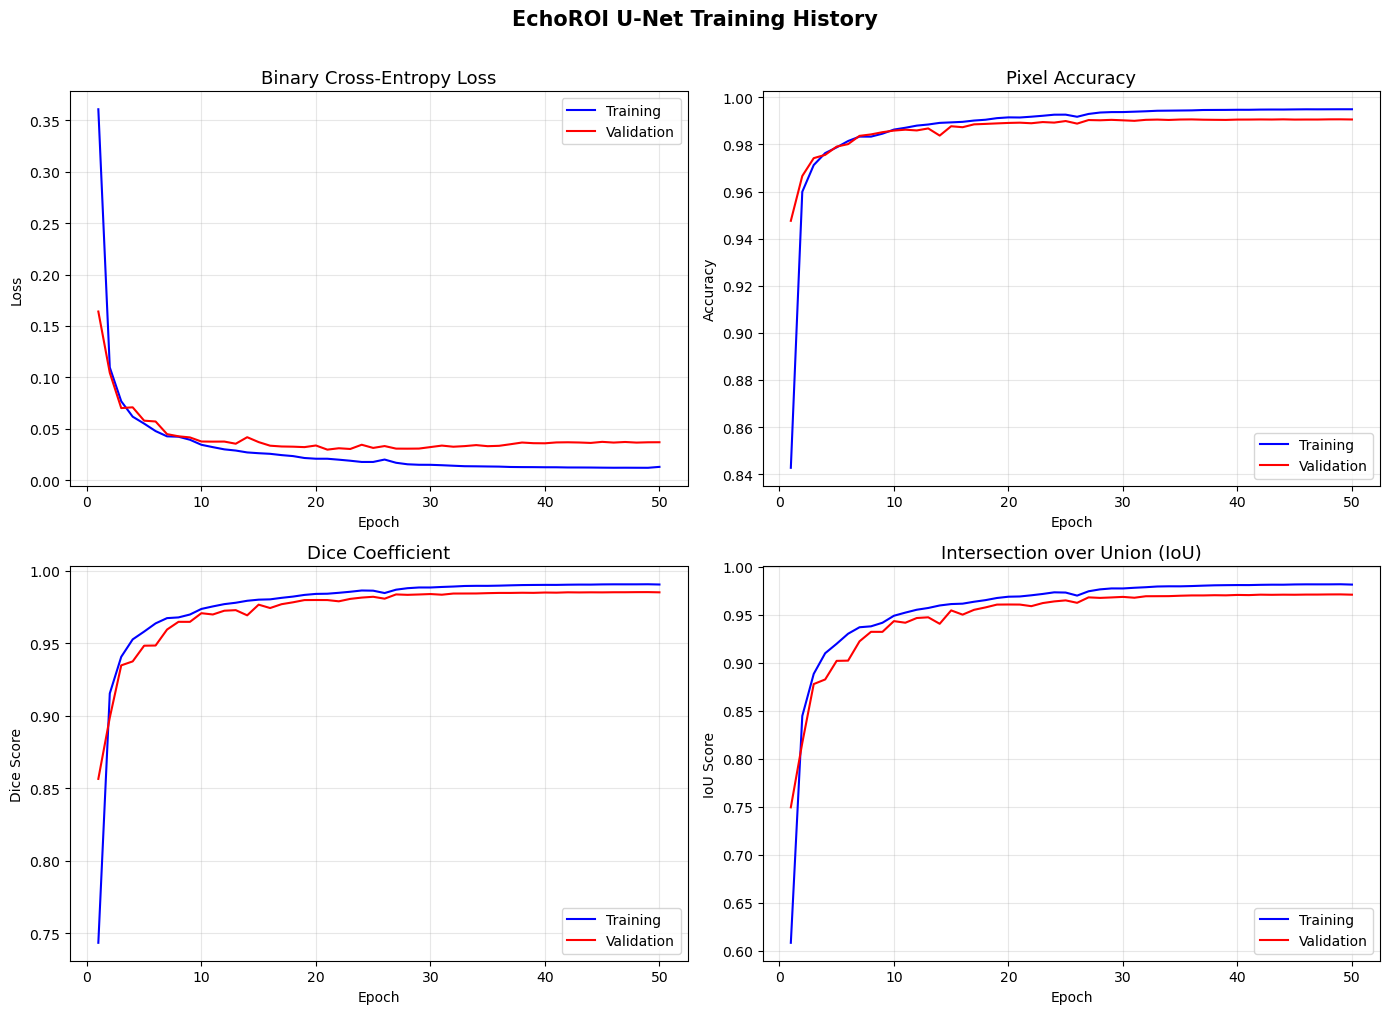

Saved: training_results/training_history.png


In [ ]:
epochs = [int(r['epoch']) + 1 for r in log]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Composite loss (BCE + Dice + TV)
axes[0, 0].plot(epochs, [float(r['loss']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[0, 0].plot(epochs, [float(r['val_loss']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[0, 0].set_title('Composite Loss (BCE + Dice + TV)', fontsize=13)
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# Pixel Accuracy
axes[0, 1].plot(epochs, [float(r['accuracy']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[0, 1].plot(epochs, [float(r['val_accuracy']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[0, 1].set_title('Pixel Accuracy', fontsize=13)
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# IoU (Jaccard) — primary metric
axes[1, 0].plot(epochs, [float(r['iou_score']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[1, 0].plot(epochs, [float(r['val_iou_score']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[1, 0].set_title('IoU (Jaccard Index) — Primary Metric', fontsize=13)
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('IoU Score')
axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

# Dice Coefficient
axes[1, 1].plot(epochs, [float(r['dice_coefficient']) for r in log], 'b-', label='Training', linewidth=1.5)
axes[1, 1].plot(epochs, [float(r['val_dice_coefficient']) for r in log], 'r-', label='Validation', linewidth=1.5)
axes[1, 1].set_title('Dice Coefficient', fontsize=13)
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Dice Score')
axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('EchoROI U-Net Training History', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('training_results/training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_results/training_history.png")

## 3. Load Trained Model

In [3]:
import tensorflow as tf
from echoroi.preprocessing import UltrasoundPreprocessor
from echoroi.training import calculate_metrics

# Load the trained model
model_path = "models/echoroi_unified.keras"
model = tf.keras.models.load_model(model_path, compile=False)

print(f"Model loaded from: {model_path}")
print(f"Input shape:  {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Parameters:   {model.count_params():,}")
print(f"File size:    {os.path.getsize(model_path) / 1e6:.1f} MB")

Model loaded from: models/echoroi_unified.keras
Input shape:  (None, 256, 256, 1)
Output shape: (None, 256, 256, 1)
Parameters:   31,030,593
File size:    372.5 MB


## 4. Evaluate on Validation Data

Reload the full dataset, apply the same 80/20 split, and evaluate the best model on the held-out validation set.

In [ ]:
from sklearn.model_selection import train_test_split
from echoroi.training import dataset_label_from_filename

# Load dataset
preprocessor = UltrasoundPreprocessor((256, 256))
X, Y = preprocessor.load_dataset("data/images", "data/masks")

# Build stratification labels from filenames
pairs = preprocessor.validate_data_paths("data/images", "data/masks")
labels = [dataset_label_from_filename(p) for p, _ in pairs]

# Same stratified split as training (random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=labels
)
print(f"Validation set: {X_val.shape[0]} samples (stratified by dataset source)")

# Predict
Y_pred = model.predict(X_val, verbose=1)

# Calculate metrics
val_metrics = calculate_metrics(Y_val, Y_pred)
print("\nValidation Metrics:")
print("-" * 40)
for k, v in val_metrics.items():
    if k not in ('intersection', 'union'):
        print(f"  {k:20s}: {v:.4f}")

Loaded 1206 samples → Images (1206, 256, 256, 1), Masks (1206, 256, 256, 1)
Validation set: 242 samples
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 669ms/step

Validation Metrics:
----------------------------------------
  dice                : 0.9880
  iou                 : 0.9763
  accuracy            : 0.9906
  sensitivity         : 0.9894
  specificity         : 0.9914


## 5. Prediction Visualization

Display sample predictions comparing input images, ground truth masks, and model predictions.

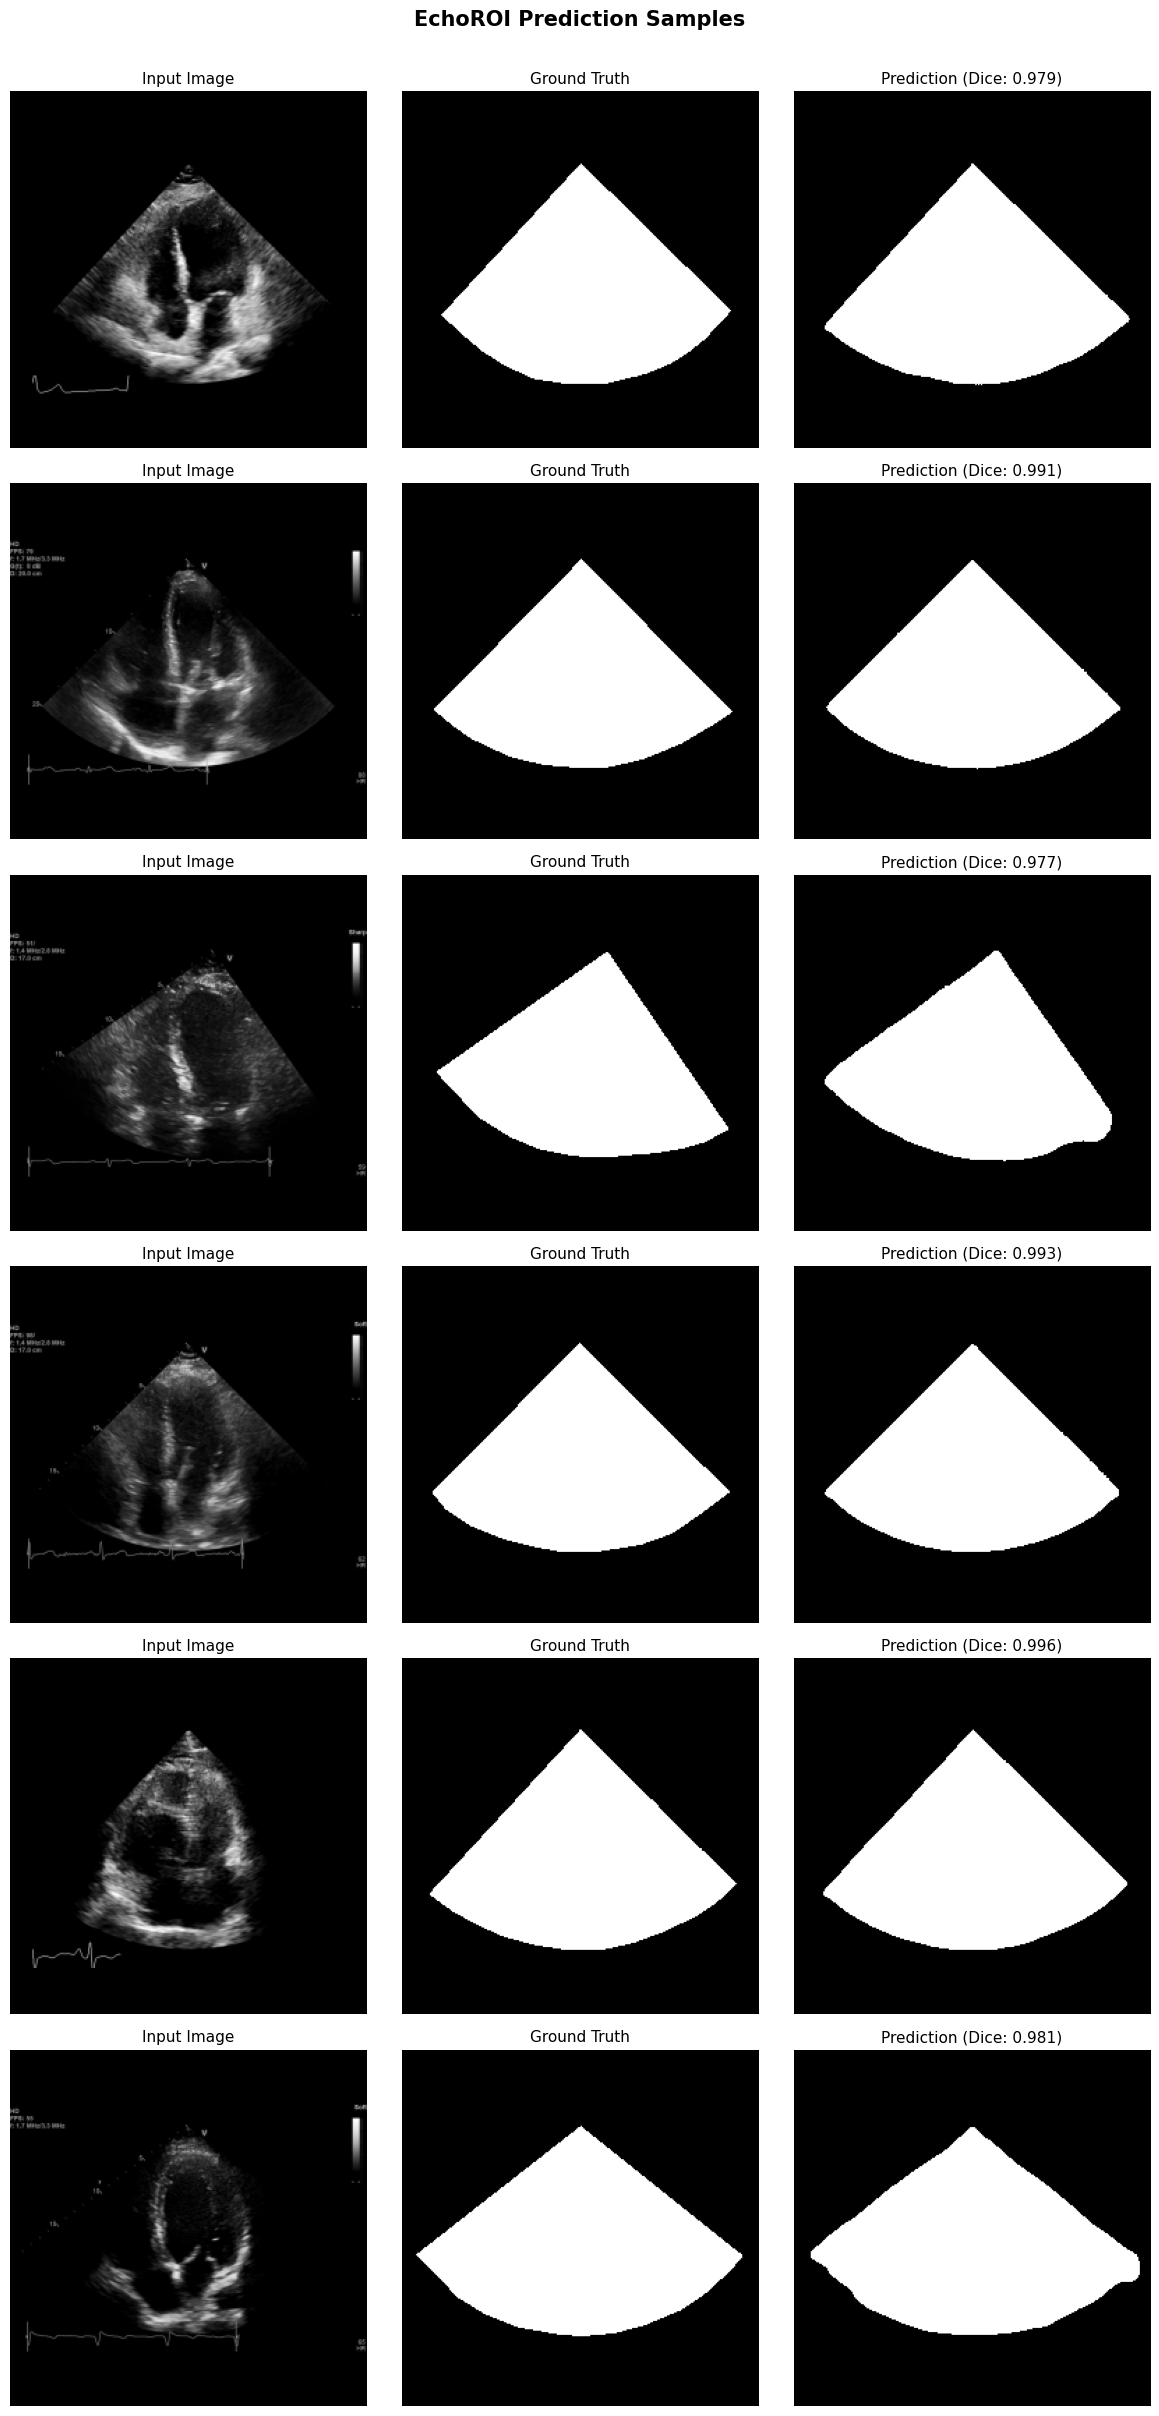

Saved: training_results/prediction_samples.png


In [ ]:
n_samples = 6
np.random.seed(42)
indices = np.random.choice(X_val.shape[0], n_samples, replace=False)

fig, axes = plt.subplots(n_samples, 3, figsize=(12, 4 * n_samples))

for i, idx in enumerate(indices):
    img = X_val[idx].squeeze()
    gt = Y_val[idx].squeeze()
    pred = (Y_pred[idx].squeeze() > 0.5).astype(np.float32)
    sample_iou = calculate_metrics(Y_val[idx:idx+1], Y_pred[idx:idx+1])['iou']

    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title('Input Image', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(gt, cmap='gray')
    axes[i, 1].set_title('Ground Truth', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(pred, cmap='gray')
    axes[i, 2].set_title(f'Prediction (IoU: {sample_iou:.3f})', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('EchoROI Prediction Samples', fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('training_results/prediction_samples.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: training_results/prediction_samples.png")

## 6. Per-Sample IoU Distribution

Compute IoU (Jaccard) score for each validation sample individually to assess consistency.

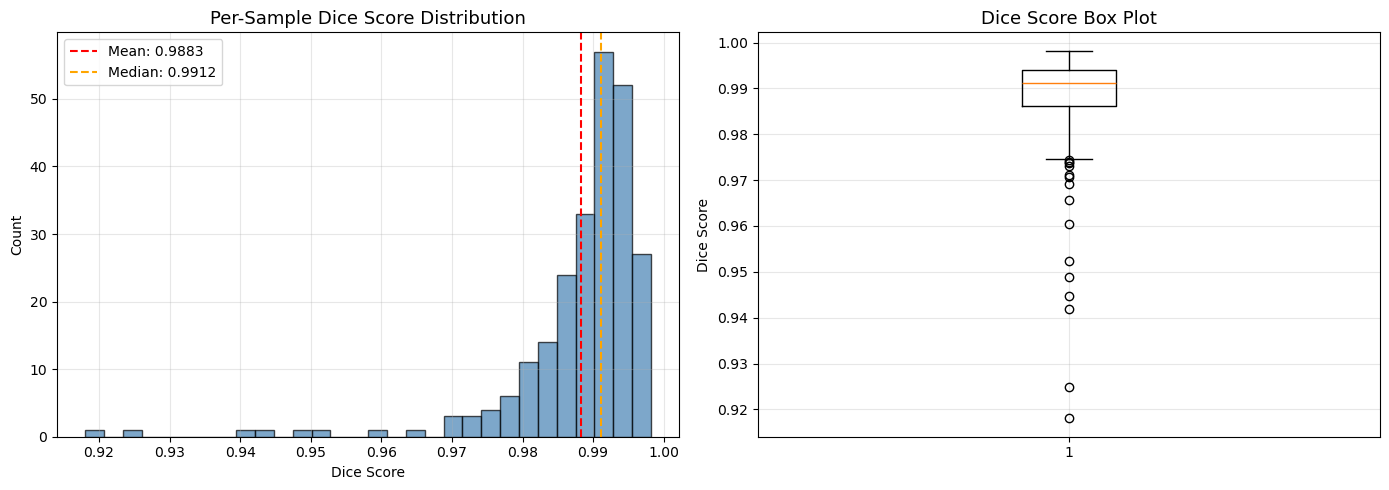


Per-Sample Dice Statistics:
  Mean:   0.9883
  Median: 0.9912
  Std:    0.0103
  Min:    0.9180
  Max:    0.9982
  >0.95:  237 / 242 (97.9%)


In [ ]:
# Per-sample IoU scores
per_sample_iou = []
for i in range(X_val.shape[0]):
    m = calculate_metrics(Y_val[i:i+1], Y_pred[i:i+1])
    per_sample_iou.append(m['iou'])

per_sample_iou = np.array(per_sample_iou)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(per_sample_iou, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(per_sample_iou), color='red', linestyle='--',
                label=f'Mean: {np.mean(per_sample_iou):.4f}')
axes[0].axvline(np.median(per_sample_iou), color='orange', linestyle='--',
                label=f'Median: {np.median(per_sample_iou):.4f}')
axes[0].set_title('Per-Sample IoU (Jaccard) Distribution', fontsize=13)
axes[0].set_xlabel('IoU Score')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(per_sample_iou, vert=True)
axes[1].set_title('IoU Score Box Plot', fontsize=13)
axes[1].set_ylabel('IoU Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPer-Sample IoU Statistics:")
print(f"  Mean:   {np.mean(per_sample_iou):.4f}")
print(f"  Median: {np.median(per_sample_iou):.4f}")
print(f"  Std:    {np.std(per_sample_iou):.4f}")
print(f"  Min:    {np.min(per_sample_iou):.4f}")
print(f"  Max:    {np.max(per_sample_iou):.4f}")
print(f"  >0.90:  {np.sum(per_sample_iou > 0.90)} / {len(per_sample_iou)}"
      f" ({100*np.mean(per_sample_iou > 0.90):.1f}%)")

## Summary

*Metrics below will be updated after retraining with the composite loss.*

| Metric | Value |
|---|---|
| **IoU (Jaccard)** | *pending* |
| **Dice Coefficient** | *pending* |
| **Pixel Accuracy** | *pending* |
| **Sensitivity** | *pending* |
| **Specificity** | *pending* |

**Loss function:** BCE + Dice + Total Variation (see Section 1 for details).
**Split:** 80/20, stratified by source dataset.
**Checkpoint selection:** Best `val_iou_score`.

The model and all training artifacts are saved in:
- `models/echoroi_unified.keras` — Trained Keras model
- `models/echoroi_unified.onnx` — ONNX export (see notebook 02)
- `training_results/` — Metrics, plots, and training log